## Calibrate
This code is a replacement for GNBF_2_calibrate_from_Xtlvecs

In [2]:
# Generic imports
from mpl_toolkits.mplot3d import Axes3D
import numpy as np
import matplotlib.pyplot as plt
import PIL
import f90nml
from matplotlib.widgets import Slider, Button

# Reloading
from importlib import reload

# Local imports
import sys
sys.path.append('../')
import imagestuff as ims
from imagestuff import ExtlvecxAngleManager
import local as ims2

CUDA not available.


In [3]:
%matplotlib widget

### Getting parameters for the response functions

SEMimages/case1.0-A.bmp
SEMimages/case1.0-B.bmp
SEMimages/case1.0-C.bmp
SEMimages/case1.0-D.bmp
nboxes = 3


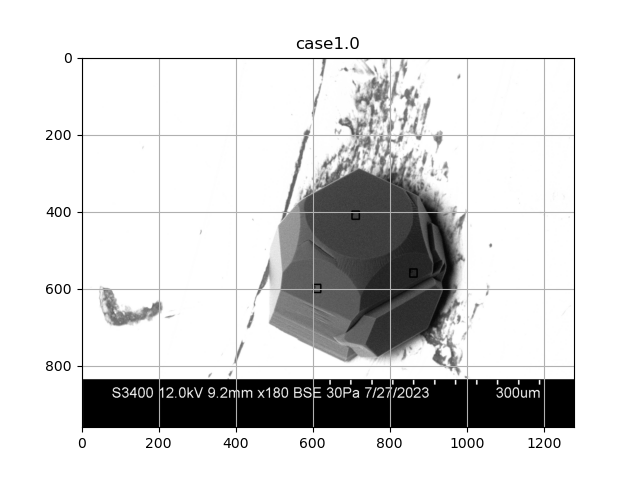

In [5]:
# For development
reload(ims2)

# Open up a figure and set up the drawing function
imageroot = 'case1.0'
dx,dy,cA,cB,cC,cD,Filename = ims.getc2('', 'SEMimages/', imageroot,'A')
im = PIL.Image.open(Filename)
draw = PIL.ImageDraw.Draw(im)
plt.figure()

# Specify the calibration boxes
nx1list,nx2list,ny1list,ny2list = ims2.get_box_lists('Boxes.nml',draw)

# Setup the angle manager with default Euler angles
alpha_default = -177.0
beta_default = 21
gamma_default = 19
xorigin = 712
yorigin = 684
angleManager = ExtlvecxAngleManager(xorigin,yorigin,alpha_default, beta_default, gamma_default)
angleManager.calculate_starts()
angleManager.construct_rotation_matrices()

# Get the nvecs
cvecdir = 'pointingdown' # Alternative is 'pointingup' 
boxa= 'pyramidal' # Alternative is 'prismatic'
boxb= 'pyramidal' # Alternative is 'prismatic'
navec, nbvec, ndvec = ims2.get_nvecs(angleManager, draw, cvecdir, boxa, boxb, nx1list, ny1list)

# Finish up
plt.title(imageroot)
plt.imshow(im,cmap = 'Greys_r', vmin = 0,vmax = 255)
plt.grid(True)

### Fine-tuning the Euler angles

In [7]:
reload(ims2)
ims2.get_box_lists('Boxes.nml',draw)
desired_facet_angles = [[0,1,62.0],[0,2,62.0]]
print('desired_facet_angles', desired_facet_angles)

angle_number = 4
angle_range = 3
alpha_min = np.max([-180, alpha_default-angle_range]); alpha_max = np.min([180,alpha_default+angle_range]); print(alpha_min,alpha_max)
beta_min = np.max([0, beta_default-angle_range]); beta_max = np.min([180, beta_default+angle_range]); print (beta_min,beta_max)
gamma_min = np.max([-180, gamma_default-angle_range]); gamma_max = np.min([180,gamma_default+angle_range]); print(gamma_min,gamma_max)
least_error = 1e5
for alpha in np.linspace(alpha_min,alpha_max,angle_number):
    for beta in np.linspace(beta_min,beta_max,angle_number):
        for gamma in np.linspace(gamma_min,gamma_max,angle_number):
            angleManager.alpha   = alpha
            angleManager.beta    = beta
            angleManager.gamma   = gamma
            angleManager.update()
            navec, nbvec, ndvec = ims2.get_nvecs(\
                angleManager, draw, cvecdir, boxa, boxb, nx1list, ny1list)
            pA, pB, pC, pD, response_function_error = ims2.response_function(\
                navec,nbvec,ndvec,cA,cB,cC,cD,nx1list,nx2list,ny1list,ny2list,imageroot)
            surfaces, sfunctions, retrieval_error = ims2.retrieve_segments(\
                pA, pB, pC, pD, cA, cB, cC, cD, nx1list, nx2list, ny1list, ny2list, \
                imageroot, dx=dx, dy=dy, overlapping=False, desired_facet_angles=desired_facet_angles)
            if retrieval_error < least_error:
                alpha_best = alpha
                beta_best = beta
                gamma_best = gamma
                pA_best = pA
                pB_best = pB
                pC_best = pC
                pD_best = pD
                least_error = retrieval_error
                print('New alpha, beta, gamma = ', alpha_best,beta_best,gamma_best,retrieval_error)
print('best alpha, beta, gamma, pA, and error = ', alpha_best, beta_best, gamma_best, pA_best, least_error)

# angleManager.alpha   = alpha_best
# angleManager.beta    = beta_best
# angleManager.gamma   = gamma_best
# angleManager.update()
# navec, nbvec, ndvec = ims2.get_nvecs(angleManager, draw, cvecdir, boxa, boxb, nx1list, ny1list)
# error = ims2.response_function(navec,nbvec,ndvec,cA,cB,cC,cD,nx1list,nx2list,ny1list,ny2list,imageroot,graphics=True)
# print(error)

# im = PIL.Image.open(Filename)
# draw = PIL.ImageDraw.Draw(im)
# plt.figure()

# ims2.get_box_lists('Boxes.nml',draw)

# angleManager.alpha   = alpha_best
# angleManager.beta    = beta_best
# angleManager.gamma   = gamma_best
# angleManager.update()
# navec, nbvec, ndvec = ims2.get_nvecs(angleManager, draw, cvecdir, boxa, boxb, nx1list, ny1list)

# Finish up
plt.title(imageroot)
plt.imshow(im,cmap = 'Greys_r', vmin = 0,vmax = 255)
plt.grid(True)

nboxes = 3
desired_facet_angles [[0, 1, 62.0], [0, 2, 62.0]]
-180.0 -174.0
18 24
16 22
nsegments  3
Std deviation in input signal is 5.0
Std deviation in a priori is 15.0

Segment: 0 ( 1 of 3 )
for 600 590
Observed intensities (detector B):
mean, max, min = 44.3925 60.0 31.0
<diff>, std(diff), di2 = 4.358850322933524 24.42340070754246 35615.18299209945
<diff>, std(diff), di2 = 4.293672550701306 6.712683907407318 1265.887593380559
<diff>, std(diff), di2 = 3.970236265186535 5.259970017146684 38.308596117445475
<diff>, std(diff), di2 = 3.890455424346018 5.256010538078167 0.4318680456326357

Segment: 1 ( 2 of 3 )
for 850 550
Observed intensities (detector B):
mean, max, min = 50.51 71.0 35.0
<diff>, std(diff), di2 = 10.285725322933526 34.15434961155043 73193.57086203402
<diff>, std(diff), di2 = 7.2963457166870604 11.235494618595478 6195.387486767042
<diff>, std(diff), di2 = 5.6949246829286695 7.72160044275428 1012.3163739936265
<diff>, std(diff), di2 = 4.761108910488755 7.315440536870158 1

### Checking how we did

response_function_error  66.50146305797365
nsegments  3
Std deviation in input signal is 5.0
Std deviation in a priori is 15.0

Segment: 0 ( 1 of 3 )
for 600 590
Observed intensities (detector B):
mean, max, min = 44.3925 60.0 31.0
<diff>, std(diff), di2 = 4.281604760894018 23.677925638315184 33284.90390066771
<diff>, std(diff), di2 = 4.2761586428826615 6.582751000782749 1080.2141243032322
<diff>, std(diff), di2 = 3.9975811843854876 5.332329481155873 27.15696816769249
<diff>, std(diff), di2 = 3.936381099942076 5.3335077908039725 0.2485880808082932

Segment: 1 ( 2 of 3 )
for 850 550
Observed intensities (detector B):
mean, max, min = 50.51 71.0 35.0
<diff>, std(diff), di2 = 10.208479760894013 31.394192456556798 61546.121065936764
<diff>, std(diff), di2 = 7.34350081330488 10.087529187049201 4270.931944654899
<diff>, std(diff), di2 = 5.976013382171212 7.505866694018441 500.8710806462971
<diff>, std(diff), di2 = 5.321915620925795 7.4345655161718955 54.29837817872761
<diff>, std(diff), di2 

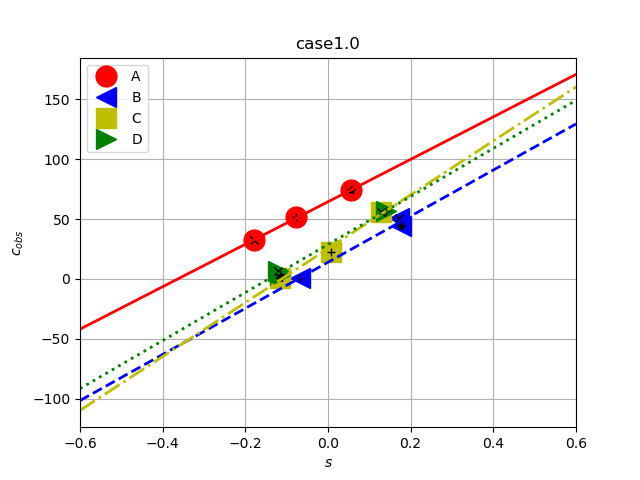

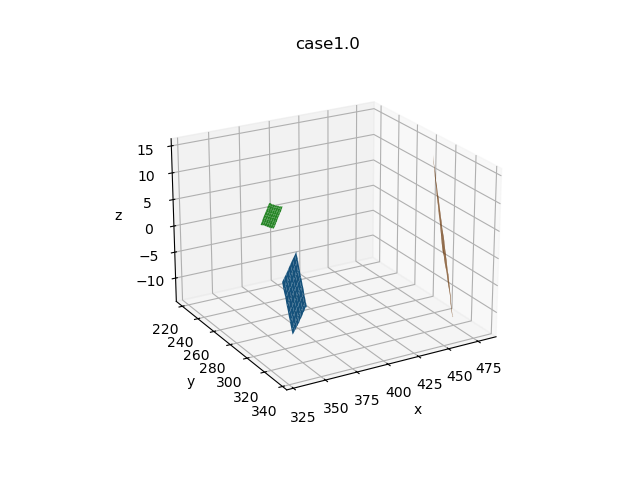

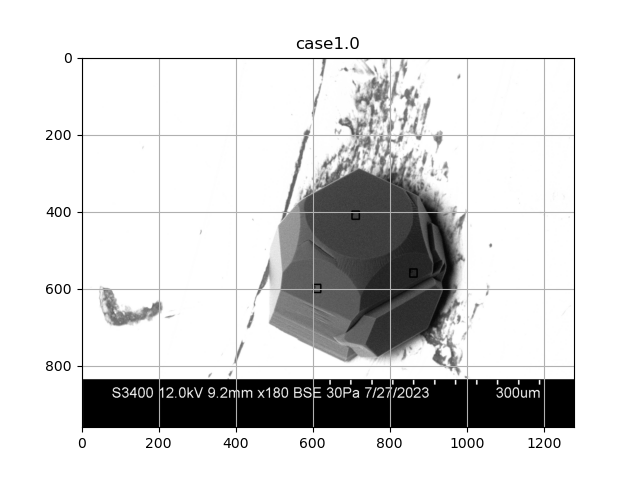

In [9]:
pA, pB, pC, pD, response_function_error = ims2.response_function(\
    navec,nbvec,ndvec,cA,cB,cC,cD,nx1list,nx2list,ny1list,ny2list,imageroot, graphics=True)
print('response_function_error ', response_function_error)

surfaces, sfunctions, angle_error = ims2.retrieve_segments(\
    pA, pB, pC, pD, cA, cB, cC, cD, nx1list, nx2list, ny1list, ny2list, \
    imageroot, dx=dx, dy=dy, overlapping=False, desired_facet_angles=desired_facet_angles, graphics=True)
print('angle_error ', angle_error)

plt.figure()
im = PIL.Image.open(Filename)
draw = PIL.ImageDraw.Draw(im)

ims2.get_box_lists('Boxes.nml',draw)

angleManager.alpha   = alpha_best
angleManager.beta    = beta_best
angleManager.gamma   = gamma_best
angleManager.update()
navec, nbvec, ndvec = ims2.get_nvecs(angleManager, draw, cvecdir, boxa, boxb, nx1list, ny1list)


# Finish up
plt.title(imageroot)
plt.imshow(im,cmap = 'Greys_r', vmin = 0,vmax = 255)
plt.grid(True)

### Saving the calibration

In [11]:
Calibrationfile = 'Calibration.nml'
cfile = open(Calibrationfile,'w')
cfile.write('&Calibration\n')
cfile.write('   '+'pA = '+str(pA[0])+',  '+str(pA[1])+'\n')
cfile.write('   '+'pB = '+str(pB[0])+',  '+str(pB[1])+'\n')
cfile.write('   '+'pC = '+str(pC[0])+',  '+str(pC[1])+'\n')
cfile.write('   '+'pD = '+str(pD[0])+',  '+str(pD[1])+'\n')
cfile.write('/ \n')
cfile.close()

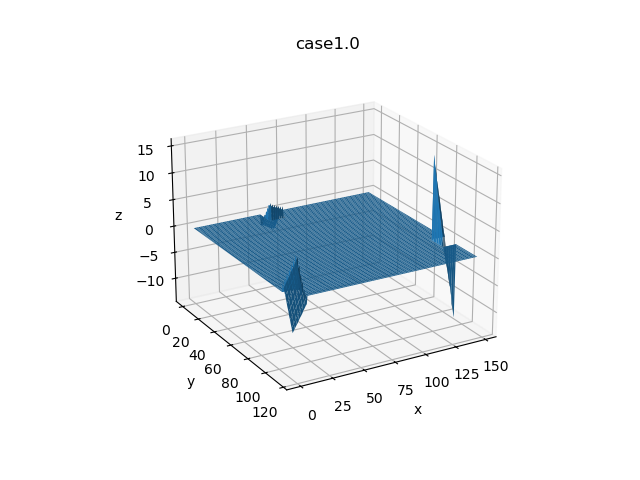

In [12]:
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.invert_yaxis() # invert y axis (this fixes the right-hand-oriented vs left-hand-oriented system)
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('z')
ax.set_title(imageroot)
ax.view_init(azim=-120,elev=22)
ax.plot_surface(surfaces[0], surfaces[1], surfaces[2], rstride=3 ,cstride=3)

SEMimages/case1.0-A.bmp
SEMimages/case1.0-B.bmp
SEMimages/case1.0-C.bmp
SEMimages/case1.0-D.bmp
nboxes = 3


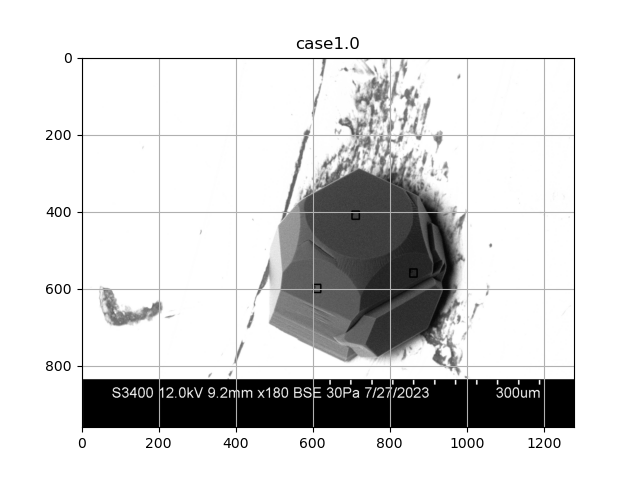

In [27]:
# Open up a figure and set up the drawing function
imageroot = 'case1.0'
dx,dy,cA,cB,cC,cD,Filename = ims.getc2('', 'SEMimages/', imageroot,'A')
im = PIL.Image.open(Filename)
draw = PIL.ImageDraw.Draw(im)
plt.figure()

# Specify the calibration boxes
nx1list,nx2list,ny1list,ny2list = ims2.get_box_lists('Boxes.nml',draw)


angleManager = ExtlvecxAngleManager(xorigin,yorigin,alpha_best, beta_best, gamma_best)
angleManager.calculate_starts()
angleManager.construct_rotation_matrices()

# Get the nvecs
cvecdir = 'pointingdown' # Alternative is 'pointingup' 
boxa= 'pyramidal' # Alternative is 'prismatic'
boxb= 'pyramidal' # Alternative is 'prismatic'
navec, nbvec, ndvec = ims2.get_nvecs(angleManager, draw, cvecdir, boxa, boxb, nx1list, ny1list)


# Finish up
plt.title(imageroot)
plt.imshow(im,cmap = 'Greys_r', vmin = 0,vmax = 255)
plt.grid(True)

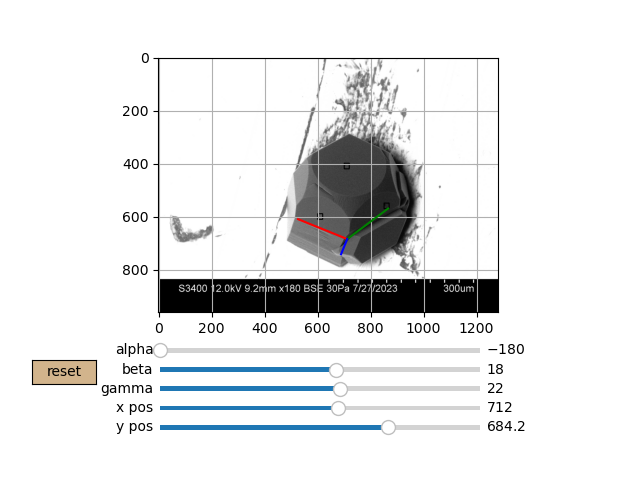

In [29]:
# setup angle manager
angleManager = ExtlvecxAngleManager(712,684.2,alpha_best,beta_best,gamma_best)
angleManager.calculate_starts()
angleManager.construct_rotation_matrices()

# make figure
fig, ax = plt.subplots()
## move main area up a little bit
plt.subplots_adjust(bottom=0.35)

# base setup
## display background image
plt.imshow(im,cmap = 'Greys_r', vmin = 0,vmax = 255)
## misc
plt.grid(True)

# set data
## get the data for each of the three
x0,y0,x1,y1,x2,y2 = angleManager.makeLines()
### plt.plot returns two outputs, and we only want to save the first one,
### so a comma is needed
vecA, = plt.plot(x0,y0,color='red')
vecB, = plt.plot(x1,y1,color='green')
vecC, = plt.plot(x2,y2,color='blue')

# add sliders
axcolor = 'white'
## set areas (axes)
### format is [left, bottom, width, height]
ax0 = plt.axes([0.25, 0.10, 0.5, 0.02], facecolor=axcolor)
ax1 = plt.axes([0.25, 0.14, 0.5, 0.02], facecolor=axcolor)
ax2 = plt.axes([0.25, 0.18, 0.5, 0.02], facecolor=axcolor)
ax3 = plt.axes([0.25, 0.22, 0.5, 0.02], facecolor=axcolor)
ax4 = plt.axes([0.25, 0.26, 0.5, 0.02], facecolor=axcolor)
## designate areas (axes) as sliders
slider_ypos  = Slider(ax0,'y pos',0,im.size[1],valinit=angleManager.yorigin)
slider_xpos  = Slider(ax1,'x pos',0,im.size[0],valinit=angleManager.xorigin)
slider_gamma = Slider(ax2,'gamma',-180,180,valinit=angleManager.gamma)
slider_beta  = Slider(ax3,'beta', -180,180,valinit=angleManager.beta)
slider_alpha = Slider(ax4,'alpha',-180,180,valinit=angleManager.alpha)

# add reset button
## set area (axes)
axReset = plt.axes([0.05, 0.2, 0.1, 0.05])
## designate area (axes) as button
resetButton = Button(axReset, 'reset', color='tan')


def update(val):
    # this function is called every time a slider is moved.
    # It reads the sliders, and then updates the graph accordingly

    # read slider values, and send them to angleManager
    angleManager.xorigin = slider_xpos.val
    angleManager.yorigin = slider_ypos.val
    angleManager.alpha   = slider_alpha.val
    angleManager.beta    = slider_beta.val
    angleManager.gamma   = slider_gamma.val

    # update the angleManager with new information
    angleManager.update()

    # get each line and update the graph with them
    x0,y0,x1,y1,x2,y2 = angleManager.makeLines()
    vecA.set_xdata(x0)
    vecA.set_ydata(y0)
    vecB.set_xdata(x1)
    vecB.set_ydata(y1)
    vecC.set_xdata(x2)
    vecC.set_ydata(y2)

    # update graph visual
    fig.canvas.draw_idle()

# link each slider to update()
slider_xpos.on_changed(update)
slider_ypos.on_changed(update)
slider_alpha.on_changed(update)
slider_beta.on_changed(update)
slider_gamma.on_changed(update)

def reset(event):
    # resets all sliders to original positions
    slider_xpos.reset()
    slider_ypos.reset()
    slider_alpha.reset()
    slider_beta.reset()
    slider_gamma.reset()

# link reset button to reset()
resetButton.on_clicked(reset)

# system-specific. Not sure when/if you'll need this:
plt.show()

In [15]:
# Specifying the angles and origin in an output file
xtlvecsfile = 'Xtlvecs.nml'
cfile = open(xtlvecsfile,'w')
cfile.write('&Xtlvecs\n')
cfile.write('   '+'xorigin = '+str(angleManager.xorigin) +'\n')
cfile.write('   '+'yorigin = '+str(angleManager.yorigin) +'\n')
cfile.write('   '+'avec = '+\
            str(angleManager.avec[0,0])+','+\
            str(angleManager.avec[1,0])+','+\
            str(angleManager.avec[2,0])+'\n')
cfile.write('   '+'bvec = '+\
            str(angleManager.bvec[0,0])+','+\
            str(angleManager.bvec[1,0])+','+\
            str(angleManager.bvec[2,0])+'\n')
cfile.write('   '+'cvec = '+\
            str(angleManager.cvec[0,0])+','+\
            str(angleManager.cvec[1,0])+','+\
            str(angleManager.cvec[2,0])+'\n')
cfile.write('/ \n')
cfile.close()